In [1]:
from google.colab import files
uploaded = files.upload()
print("File uploaded! ✅")

Saving IPL_Matches_2008_2022.csv to IPL_Matches_2008_2022 (1).csv
File uploaded! ✅


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
print("All libraries imported! ✅")

All libraries imported! ✅


In [3]:
df = pd.read_csv('IPL_Matches_2008_2022.csv')
print("Total matches:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Total matches: 950
Columns: ['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2', 'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam', 'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players', 'Team2Players', 'Umpire1', 'Umpire2']


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [4]:
df_clean = df[['Team1', 'Team2', 'Venue',
               'TossWinner', 'TossDecision', 'WinningTeam']].copy()

# Remove abandoned matches (no winner)
df_clean = df_clean.dropna(subset=['WinningTeam'])
print("Rows after cleaning:", len(df_clean))
df_clean.head()

Rows after cleaning: 946


,Team1,Team2,Venue,TossWinner,TossDecision,WinningTeam
0,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,Gujarat Titans
1,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,Rajasthan Royals
2,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,Royal Challengers Bangalore
3,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,Gujarat Titans
4,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,Punjab Kings


In [5]:
le = LabelEncoder()
df_clean['Team1_enc']        = le.fit_transform(df_clean['Team1'])
df_clean['Team2_enc']        = le.fit_transform(df_clean['Team2'])
df_clean['Venue_enc']        = le.fit_transform(df_clean['Venue'])
df_clean['TossWinner_enc']   = le.fit_transform(df_clean['TossWinner'])
df_clean['TossDecision_enc'] = le.fit_transform(df_clean['TossDecision'])
df_clean['Winner_enc']       = le.fit_transform(df_clean['WinningTeam'])
print("Label Encoding done! ✅")
df_clean[['Team1','Team1_enc','WinningTeam','Winner_enc']].head()

Label Encoding done! ✅


,Team1,Team1_enc,WinningTeam,Winner_enc
0,Rajasthan Royals,13,Gujarat Titans,5
1,Royal Challengers Bangalore,16,Rajasthan Royals,13
2,Royal Challengers Bangalore,16,Royal Challengers Bangalore,16
3,Rajasthan Royals,13,Gujarat Titans,5
4,Sunrisers Hyderabad,17,Punjab Kings,12


In [6]:
# X = inputs (clues), y = output (answer)
X = df_clean[['Team1_enc','Team2_enc','Venue_enc',
              'TossWinner_enc','TossDecision_enc']]
y = df_clean['Winner_enc']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale — bring all numbers to same range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training size:", len(X_train))
print("Testing size :", len(X_test))
print("Data is ready for ML! ✅")

Training size: 756
Testing size : 190
Data is ready for ML! ✅


In [7]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled)) * 100
print("1. Logistic Regression:", round(lr_acc,2), "%")

# Model 2 - Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test_scaled)) * 100
print("2. Decision Tree      :", round(dt_acc,2), "%")

# Model 3 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test_scaled)) * 100
print("3. Random Forest      :", round(rf_acc,2), "%")

1. Logistic Regression: 17.89 %
2. Decision Tree      : 36.32 %
3. Random Forest      : 41.05 %


In [9]:

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test_scaled)) * 100
print("4. SVM           :", round(svm_acc,2), "%")

# Model 5 - KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test_scaled)) * 100
print("5. KNN           :", round(knn_acc,2), "%")

# Model 6 - Neural Network (takes ~15 secs!)
print("Training Neural Network... please wait...")
nn = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
nn.fit(X_train_scaled, y_train)
nn_acc = accuracy_score(y_test, nn.predict(X_test_scaled)) * 100
print("6. Neural Network:", round(nn_acc,2), "%")
print("All 6 models trained! ✅")

4. SVM           : 31.58 %
5. KNN           : 34.74 %
Training Neural Network... please wait...
6. Neural Network: 40.0 %
All 6 models trained! ✅


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


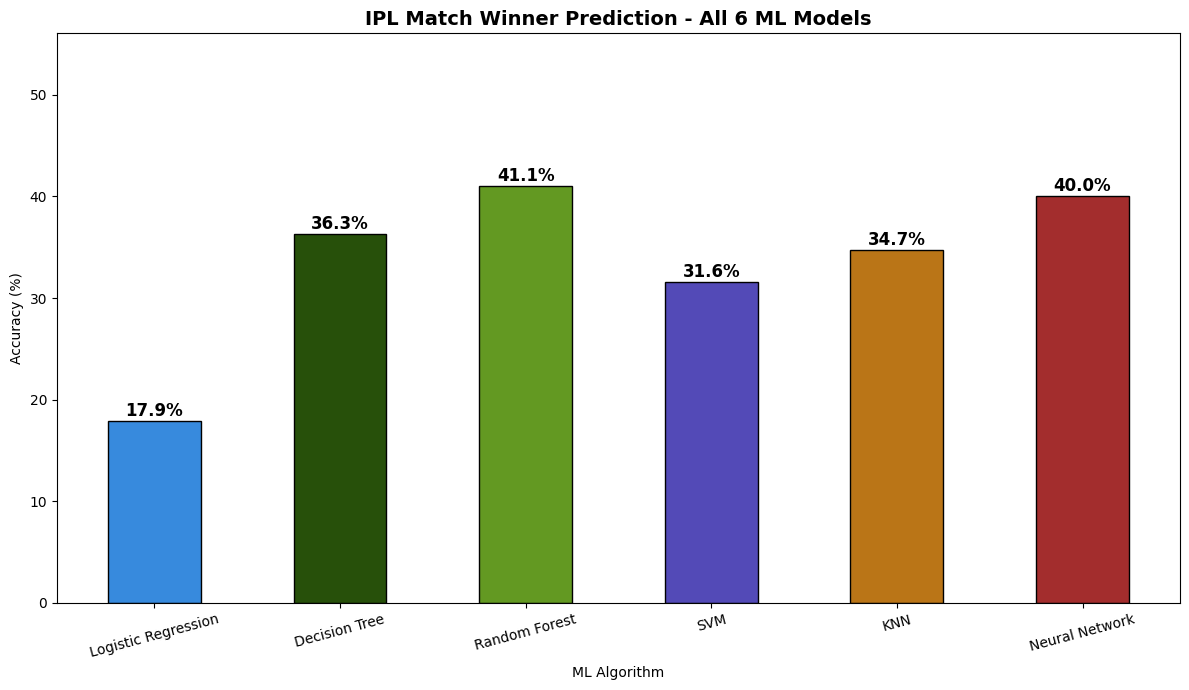

Best Model: Random Forest with 41.05 %


In [10]:
models = ['Logistic Regression','Decision Tree','Random Forest',
          'SVM','KNN','Neural Network']
scores = [lr_acc, dt_acc, rf_acc, svm_acc, knn_acc, nn_acc]
colors = ['#378ADD','#27500A','#639922','#534AB7','#BA7517','#A32D2D']

plt.figure(figsize=(12,7))
bars = plt.bar(models, scores, color=colors, edgecolor='black', width=0.5)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             str(round(score,1))+'%', ha='center', fontsize=12, fontweight='bold')
plt.title('IPL Match Winner Prediction - All 6 ML Models', fontsize=14, fontweight='bold')
plt.xlabel('ML Algorithm')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=15)
plt.ylim(0, max(scores)+15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
best = models[scores.index(max(scores))]
print("Best Model:", best, "with", round(max(scores),2), "%")


In [12]:
le_team  = LabelEncoder().fit(df_clean['Team1'])
le_venue = LabelEncoder().fit(df_clean['Venue'])
le_toss  = LabelEncoder().fit(df_clean['TossWinner'])
le_dec   = LabelEncoder().fit(df_clean['TossDecision'])
le_win   = LabelEncoder().fit(df_clean['WinningTeam'])

def predict_winner(team1, team2, venue, toss_winner, toss_decision):
    t1 = le_team.transform([team1])[0]
    t2 = le_team.transform([team2])[0]
    v  = le_venue.transform([venue])[0]
    tw = le_toss.transform([toss_winner])[0]
    td = le_dec.transform([toss_decision])[0]
    inp  = scaler.transform([[t1, t2, v, tw, td]])
    pred = rf.predict(inp)[0]
    return le_win.inverse_transform([pred])[0]

print("All teams:", sorted(df_clean['Team1'].unique()))

r1 = predict_winner('Chennai Super Kings', 'Mumbai Indians',
                    'Wankhede Stadium', 'Chennai Super Kings', 'bat')
print("CSK vs MI  -> Predicted Winner:", r1)

r2 = predict_winner('Royal Challengers Bangalore', 'Kolkata Knight Riders',
                    'Eden Gardens', 'Kolkata Knight Riders', 'field')
print("RCB vs KKR -> Predicted Winner:", r2)

All teams: ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']
CSK vs MI  -> Predicted Winner: Kolkata Knight Riders
RCB vs KKR -> Predicted Winner: Kolkata Knight Riders


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
